In [34]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict, Annotated,Optional,List
from langchain_groq import ChatGroq
from langgraph.graph.message import add_messages
from langchain.messages import HumanMessage,AIMessage,SystemMessage,ToolMessage
from dotenv import load_dotenv
from langchain_community.tools import TavilySearchResults
from langgraph.checkpoint.memory import InMemorySaver
from uuid import uuid4
import os
load_dotenv()

True

In [35]:
llm=ChatGroq(model="llama-3.3-70b-versatile")
search_tool=TavilySearchResults(max_results=3)
tools=[search_tool]
llm_with_tools=llm.bind_tools(tools=tools)

In [36]:
class state(TypedDict):
    messages:Annotated[List,add_messages]

In [37]:
async def llm_node(state:state)->state:
    res=await llm_with_tools.ainvoke(state["messages"])
    return {"messages":[res]}

async def router(state:state)->str:
    last_msg=state['messages'][-1]
    if last_msg.tool_calls:
        return "tools"
    return "end"

In [38]:
async def tool_node(state:state)->state:   #Earlier we would just import Toolnode and pass our tool in it
    tool_calls=state['messages'][-1].tool_calls
    tool_msg=[]
    for tools in tool_calls:
        tool_name=tools["name"]
        tool_arg=tools["args"]
        tool_id=tools["id"]

        if tool_name=="tavily_search_results_json":
            search_results=await search_tool.invoke(tool_arg)
            tool_msg=ToolMessage(
            content=str(search_results),
            tool_call_id=tool_id,
            name=tool_name
            )
            tool_msg.append(tool_msg)

    return {"messages"[tool_msg]}

In [39]:
graph=StateGraph(state)
graph.add_node("llm_node",llm_node)
graph.add_node("tool_node",tool_node)
graph.add_edge(START,"llm_node")
graph.add_conditional_edges("llm_node",router,{
    "tools":"tool_node",
    "end":END
})

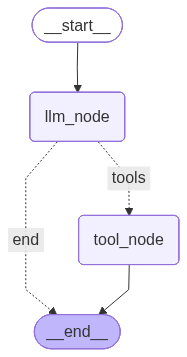

In [40]:
app=graph.compile()
config={"configurable":{"thread_id":"1"}}
memory=InMemorySaver()
app

In [41]:
res=await app.ainvo ke({"messages":HumanMessage(content="What is the current price of silver ETF?")},config=config)
print(res)

TypeError: object list can't be used in 'await' expression